In [ ]:
import pandas as pd
import numpy as np

X_train = pd.read_csv("/content/X_train.csv")
y_train = pd.read_csv("/content/y_train.csv")
X_train.head()

,job,marital,education,default,housing,loan,contact,day,month,poutcome,age_group,balance_log,balance_flag,duration_log,campaign_log,pdays_contacted,pdays_log,previous_log
0,4,1,3,0,1,0,0,0.985243,0.965926,3,4,0.507291,0,0.430097,-0.909638,0,-0.467735,-0.424985
1,9,2,2,0,1,0,0,0.985243,0.965926,3,3,-0.588304,0,-0.160655,-0.909638,0,-0.467735,-0.424985
2,2,1,2,0,1,1,0,0.985243,0.965926,3,2,-0.604089,0,-0.898547,-0.909638,0,-0.467735,-0.424985
3,1,1,2,0,1,0,0,0.985243,0.965926,3,3,0.203197,0,-0.693703,-0.909638,0,-0.467735,-0.424985
4,4,1,3,0,1,0,0,0.985243,0.965926,3,2,-0.471857,0,-0.249885,-0.909638,0,-0.467735,-0.424985


# Chọn model tốt nhất

In [ ]:
%pip install xgboost catboost

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss"
    ),
    "CatBoost": CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        verbose=0
    )
}

In [ ]:
from sklearn.model_selection import train_test_split

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train,
    test_size=0.1,           # 10% của train để làm validation
    random_state=42,
    stratify=y_train
)


In [ ]:
results = []

for name, model in models.items():
    model.fit(X_train_sub, y_train_sub)

    pred = model.predict(X_val)
    prob = model.predict_proba(X_val)[:,1]

    acc = accuracy_score(y_val, pred)
    f1  = f1_score(y_val, pred)
    auc = roc_auc_score(y_val, prob)

    results.append([name, acc, f1, auc])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1", "AUC"])
results_df

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,Model,Accuracy,F1,AUC
0,Logistic Regression,0.894655,0.385511,0.879509
1,Random Forest,0.900643,0.469194,0.905348
2,XGBoost,0.901752,0.498301,0.911014
3,CatBoost,0.899978,0.479815,0.909012


Từ kết quả cho thấy model XGBoost là model cho kết quả tốt nhất

In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV

param_dist = {
    "n_estimators": [200, 300, 500, 800, 1000],
    "learning_rate": [0.01, 0.05, 0.1, 0.15],
    "max_depth": [3, 4, 5, 6, 8],
    "subsample": [0.6, 0.7, 0.8, 1.0],
    "colsample_bytree": [0.5, 0.7, 0.9, 1.0],
    "gamma": [0, 1, 5],
    "min_child_weight": [1, 3, 5, 7]
}

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42
)

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=40,
    scoring="roc_auc",
    cv=kfold,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_sub, y_train_sub)
best_xgb = random_search.best_estimator_


Fitting 5 folds for each of 40 candidates, totalling 200 fits


**Lí cho chọn AUC làm score để chọn best params**
- Dữ liệu bị mất cân bằng (imbalanced): Các metric như Accuracy dễ gây hiểu nhầm. AUC không nhạy cảm với mất cân bằng, đánh giá mô hình công bằng hơn.

- Đánh giá mô hình trên toàn bộ threshold: AUC đo hiệu suất model mà không phụ thuộc vào một ngưỡng cắt duy nhất (như 0.5). Điều này giúp chọn mô hình tốt hơn trước khi tối ưu threshold sau.

- Đo sức mạnh xếp hạng khách hàng (ranking ability): AUC trả lời câu hỏi:
“Nếu chọn ngẫu nhiên 1 khách hàng positive và 1 negative, mô hình dự đoán score của positive cao hơn negative bao nhiêu %?”
→ Giúp xếp hạng khách hàng theo mức độ tiềm năng, quan trọng với bài toán marketing khi cần ưu tiên khách hàng có khả năng subscribe cao.

In [ ]:
print("Best Parameters:", random_search.best_params_)

Best Parameters: {'subsample': 1.0, 'n_estimators': 1000, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 1, 'colsample_bytree': 0.5}


In [ ]:
best_xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    **random_search.best_params_
)
best_xgb.fit(X_train_sub, y_train_sub)

val_pred = best_xgb.predict(X_val)
val_proba = best_xgb.predict_proba(X_val)[:, 1]

print("Accuracy:", accuracy_score(y_val, val_pred))
print("F1:", f1_score(y_val, val_pred))
print("AUC:", roc_auc_score(y_val, val_proba))


Accuracy: 0.9006431581281881
F1: 0.46919431279620855
AUC: 0.9114544863651136


ta thấy khi dùng best params thì AUC nhưng accurancy và F1 giảm do threshold chưa tối ưu.
- Threshold thông thường là 0.5, dữ liệu này là dữ liệu mất cân bằng (no chiếm 70%) nên ngưỡng này không thích hợp -> cần chọn threshold mới

In [ ]:
import numpy as np
from sklearn.metrics import f1_score

proba = best_xgb.predict_proba(X_val)[:, 1]

best_thr = 0.5
best_f1 = 0

for thr in np.arange(0.1, 0.9, 0.01):
    pred_thr = (proba >= thr).astype(int)
    f1 = f1_score(y_val, pred_thr)
    if f1 > best_f1:
        best_f1 = f1
        best_thr = thr

print("Best threshold:", best_thr)
print("Best F1:", best_f1)


Best threshold: 0.3899999999999999
Best F1: 0.571150097465887


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Dùng threshold tốt nhất tìm được
final_pred = (proba >= best_thr).astype(int)

print("Final Accuracy:", accuracy_score(y_val, final_pred))
print("Final Precision:", precision_score(y_val, final_pred))
print("Final Recall:", recall_score(y_val, final_pred))
print("Final F1:", f1_score(y_val, final_pred))

print("AUC:", roc_auc_score(y_val, proba))


Final Accuracy: 0.9024173874473276
Final Precision: 0.5871743486973948
Final Recall: 0.5559772296015181
Final F1: 0.571150097465887
AUC: 0.9114544863651136


ta thấy kết quả accurancy và f1 đã tốt hơn với threshold = 0.39

# Feature selection

In [ ]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
# RF
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

# Rút trích độ quan trọng
feature_importances = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importances

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,0
duration_log,0.318515
balance_log,0.138369
day,0.091068
job,0.057231
month,0.054747
age_group,0.053713
poutcome,0.052517
pdays_log,0.051052
campaign_log,0.046779
housing,0.027844


In [ ]:
# Đo lường dữ liệu của các features với biến target
mi = mutual_info_classif(X_train, y_train)
features_mi = pd.Series(
    mi,
    index=X_train.columns
).sort_values(ascending=False)

features_mi

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,0
duration_log,0.071434
poutcome,0.035284
pdays_log,0.030555
balance_log,0.021619
month,0.018766
housing,0.016087
previous_log,0.012456
age_group,0.011243
pdays_contacted,0.009648
job,0.007650


In [ ]:
# 0. Gán index là tên feature
df_score = pd.DataFrame({
    "FI": feature_importances,
    "MI": mi
}, index=X_train.columns)   # <-- DÒNG QUAN TRỌNG NHẤT

# 1. Chuẩn hóa giá trị
df_score["FI_norm"] = df_score["FI"] / df_score["FI"].max()
df_score["MI_norm"] = df_score["MI"] / df_score["MI"].max()

# 2. Tính điểm tổng hợp
df_score["score"] = 0.7 * df_score["FI_norm"] + 0.3 * df_score["MI_norm"]

# 3. Sort theo score -- không reset index
df_score_sorted = df_score.sort_values("score", ascending=False)

print("TOP FEATURE RANKING")
print(df_score_sorted)


TOP FEATURE RANKING
                       FI        MI   FI_norm   MI_norm     score
duration_log     0.318515  0.071434  1.000000  1.000000  1.000000
balance_log      0.138369  0.021619  0.434419  0.302638  0.394885
poutcome         0.052517  0.035284  0.164882  0.493941  0.263600
pdays_log        0.051052  0.030555  0.160281  0.427738  0.240518
day              0.091068  0.002706  0.285916  0.037875  0.211503
month            0.054747  0.018766  0.171881  0.262708  0.199129
age_group        0.053713  0.011243  0.168637  0.157397  0.165265
job              0.057231  0.007650  0.179679  0.107087  0.157901
campaign_log     0.046779  0.006205  0.146867  0.086864  0.128866
housing          0.027844  0.016087  0.087418  0.225199  0.128752
previous_log     0.023657  0.012456  0.074273  0.174375  0.104304
education        0.025591  0.006926  0.080345  0.096958  0.085329
marital          0.025759  0.005672  0.080871  0.079403  0.080430
pdays_contacted  0.007154  0.009648  0.022462  0.135065 

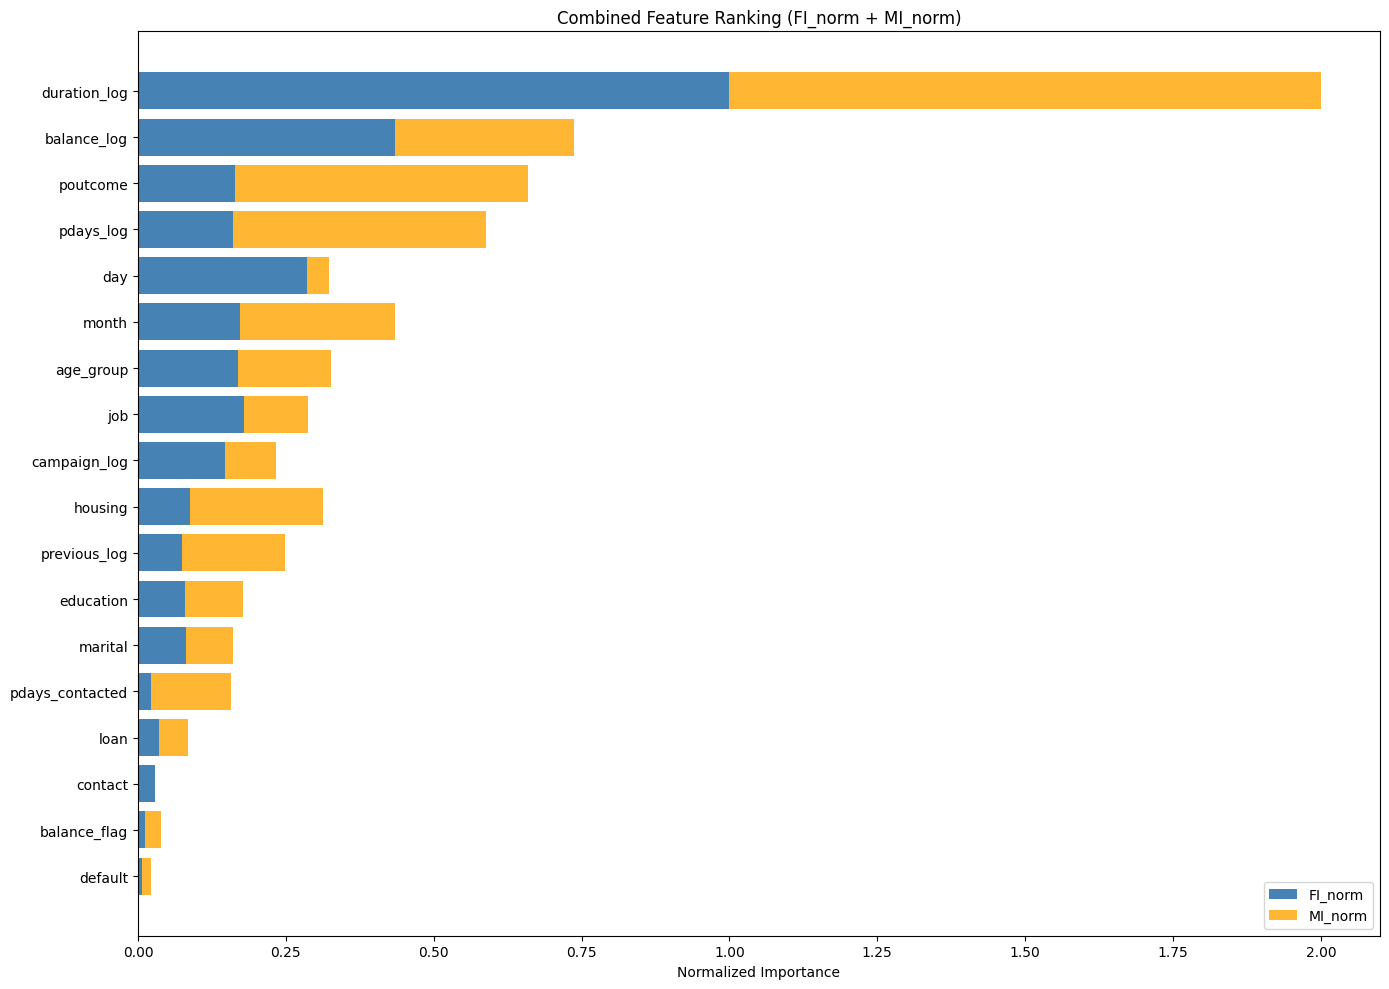

In [ ]:
# 1. Đảm bảo index là tên feature
df_score.index = X_train.columns

# 2. Sắp xếp theo score giảm dần (KHÔNG reset index)
df_score_sorted = df_score.sort_values("score", ascending=False)

# 3. Dùng df_score_sorted để plot
df_plot = df_score_sorted.copy()

plt.figure(figsize=(14, 10))

plt.barh(df_plot.index, df_plot["FI_norm"], color="steelblue", label="FI_norm")
plt.barh(df_plot.index, df_plot["MI_norm"],
         left=df_plot["FI_norm"], color="orange", alpha=0.8, label="MI_norm")

plt.gca().invert_yaxis()
plt.title("Combined Feature Ranking (FI_norm + MI_norm)")
plt.xlabel("Normalized Importance")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# đảm bảo index là tên feature
df_score.index = X_train.columns

# sắp xếp thứ hạng
df_score_sorted = df_score.sort_values("score", ascending=False)

In [ ]:
df_score_sorted

,FI,MI,FI_norm,MI_norm,score
duration_log,0.318515,0.071434,1.000000,1.000000,1.000000
balance_log,0.138369,0.021619,0.434419,0.302638,0.394885
poutcome,0.052517,0.035284,0.164882,0.493941,0.263600
pdays_log,0.051052,0.030555,0.160281,0.427738,0.240518
day,0.091068,0.002706,0.285916,0.037875,0.211503
month,0.054747,0.018766,0.171881,0.262708,0.199129
age_group,0.053713,0.011243,0.168637,0.157397,0.165265
job,0.057231,0.007650,0.179679,0.107087,0.157901
campaign_log,0.046779,0.006205,0.146867,0.086864,0.128866
housing,0.027844,0.016087,0.087418,0.225199,0.128752


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score
import numpy as np

# chạy với best params và best threshold của model đã tìm được ở trên

def feature_selection_threshold(
    min_thr=0.05, max_thr=0.35, step=0.05, min_features=3,
    n_splits=5
):
    results = []

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    thresholds = np.arange(min_thr, max_thr + step, step)

    for thr in thresholds:
        feats = df_score_sorted[df_score_sorted["score"] >= thr].index.tolist()

        if len(feats) < min_features:
            continue

        auc_scores = []
        f1_scores = []

        # === Cross Validation Loop ===
        for train_idx, val_idx in skf.split(X_train, y_train):
            X_tr = X_train.iloc[train_idx][feats]
            y_tr = y_train.iloc[train_idx]

            X_va = X_train.iloc[val_idx][feats]
            y_va = y_train.iloc[val_idx]

            model = XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
                random_state=42,
                **random_search.best_params_
            )

            model.fit(X_tr, y_tr)

            proba = model.predict_proba(X_va)[:, 1]
            pred = (proba >= best_thr).astype(int)

            auc_scores.append(roc_auc_score(y_va, proba))
            f1_scores.append(f1_score(y_va, pred))

        # Lấy mean của 5 folds
        results.append((
            thr,
            len(feats),
            np.mean(auc_scores),
            np.mean(f1_scores)
        ))

    df_results = pd.DataFrame(results, columns=["threshold", "n_features", "AUC", "F1"])
    return df_results


In [ ]:
from xgboost import XGBClassifier
df_thr = feature_selection_threshold(min_thr=0, max_thr=0.35, step=0.05, min_features=3)
print(df_thr)



   threshold  n_features       AUC        F1
0       0.00          18  0.916035  0.569620
1       0.05          14  0.914964  0.568469
2       0.10          11  0.914498  0.562916
3       0.15           8  0.907069  0.560618
4       0.20           5  0.871067  0.508873
5       0.25           3  0.860866  0.478378


In [ ]:
df_thr = feature_selection_threshold(min_thr=0.05, max_thr=0.1, step=0.01, min_features=3)
print(df_thr)

   threshold  n_features       AUC        F1
0       0.05          14  0.914964  0.568469
1       0.06          13  0.915243  0.567792
2       0.07          13  0.915243  0.567792
3       0.08          13  0.915243  0.567792
4       0.09          11  0.914498  0.562916
5       0.10          11  0.914498  0.562916


Sau khi so sánh hiệu năng mô hình ở nhiều mức threshold khác nhau, threshold = 0.05 được chọn là tối ưu nhất vì các lý do:

- F1 cao nhất trong trong tất cả các mức thậm chí khi so với dùng đủ feature chỉ có AUC hơn giảm nhẹ khoảng 0.01 (không đáng kể)

- Từ 18 xuống 14 feature, giúp mô hình gọn hơn nhưng vẫn giữ hiệu năng

- Dù threshold = 0.07 có số feature ít hơn và có AUC cao hơn nhẹ (=0.0001) nhưng vì F1 của 0.05 cao hơn đáng kể so với 0.07 (=0.004) nên ưu tiên sử dụng mức threshold = 0.05

In [ ]:
threshold = 0.05

selected_features = df_score_sorted[df_score_sorted["score"] >= threshold].index.tolist()

removed_features = [f for f in X_train.columns if f not in selected_features]

print("feature removed: ", removed_features)

X_train_new = X_train[selected_features]

feature removed:  ['default', 'loan', 'contact', 'balance_flag']


In [ ]:
X_train_new.head()

,duration_log,balance_log,poutcome,pdays_log,day,month,age_group,job,campaign_log,housing,previous_log,education,marital,pdays_contacted
0,0.430097,0.507291,3,-0.467735,0.985243,0.965926,4,4,-0.909638,1,-0.424985,3,1,0
1,-0.160655,-0.588304,3,-0.467735,0.985243,0.965926,3,9,-0.909638,1,-0.424985,2,2,0
2,-0.898547,-0.604089,3,-0.467735,0.985243,0.965926,2,2,-0.909638,1,-0.424985,2,1,0
3,-0.693703,0.203197,3,-0.467735,0.985243,0.965926,3,1,-0.909638,1,-0.424985,2,1,0
4,-0.249885,-0.471857,3,-0.467735,0.985243,0.965926,2,4,-0.909638,1,-0.424985,3,1,0


# Train Model

# train/dev/test

In [ ]:
X_test = pd.read_csv("/content/X_test.csv")
y_test = pd.read_csv("/content/y_test.csv")

X_train = pd.read_csv("/content/X_train.csv")
y_train = pd.read_csv("/content/y_train.csv")

In [ ]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

In [ ]:
X_train_new = X_tr[selected_features]
X_test_new = X_test[selected_features]
X_val_new = X_val[selected_features]

In [ ]:
X_val_new.shape

(4509, 14)

In [ ]:
best_xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    early_stopping_rounds=50,
    **random_search.best_params_
)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

def train_model(best_xgb, X_train, y_train, X_test, y_test, X_val, y_val):
    # Train với early stopping để tối ưu test performance
    best_xgb.fit(
      X_train, y_train,
      eval_set=[(X_val, y_val)],
      verbose=False
    )

    # Predict
    val_pred = best_xgb.predict(X_test)
    val_proba = best_xgb.predict_proba(X_test)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, val_pred)
    f1 = f1_score(y_test, val_pred)
    auc = roc_auc_score(y_test, val_proba)

    print("=== MODEL PERFORMANCE ===")
    print("Accuracy:", acc)
    print("F1 score:", f1)
    print("AUC:", auc)
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, val_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, val_pred))

    return acc, f1, auc


In [ ]:
acc, f1, auc = train_model(best_xgb, X_tr, y_tr, X_test, y_test, X_val, y_val)

=== MODEL PERFORMANCE ===
Accuracy: 0.9174434087882823
F1 score: 0.5623529411764706
AUC: 0.9287824864555055

Confusion Matrix:
[[3895   93]
 [ 279  239]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      3988
           1       0.72      0.46      0.56       518

    accuracy                           0.92      4506
   macro avg       0.83      0.72      0.76      4506
weighted avg       0.91      0.92      0.91      4506



In [ ]:
acc, f1, auc = train_model(best_xgb, X_train_new, y_tr, X_test_new, y_test, X_val_new, y_val)

=== MODEL PERFORMANCE ===
Accuracy: 0.915889924545051
F1 score: 0.5525383707201889
AUC: 0.9278612865623899

Confusion Matrix:
[[3893   95]
 [ 284  234]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      3988
           1       0.71      0.45      0.55       518

    accuracy                           0.92      4506
   macro avg       0.82      0.71      0.75      4506
weighted avg       0.91      0.92      0.91      4506



In [ ]:
X_train_new.shape

(40575, 14)

## cross validation

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np

def cross_validate_xgb(model, X, y, cv=5):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)

    acc_scores = []
    f1_scores = []
    auc_scores = []

    fold = 1

    for train_idx, test_idx in skf.split(X, y):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Fit
        model.fit(
            X_train, y_train,
            eval_set=[(X_test, y_test)],
            verbose=False
        )

        # Predict
        pred = model.predict(X_test)
        proba = model.predict_proba(X_test)[:, 1]

        # Scores
        acc = accuracy_score(y_test, pred)
        f1 = f1_score(y_test, pred)
        auc = roc_auc_score(y_test, proba)

        acc_scores.append(acc)
        f1_scores.append(f1)
        auc_scores.append(auc)

        print(f"\n===== Fold {fold} =====")
        print("Accuracy:", acc)
        print("F1:", f1)
        print("AUC:", auc)

        fold += 1

    print("\n=============================")
    print("====== MEAN RESULTS =========")
    print("=============================")
    print("Mean Accuracy:", np.mean(acc_scores))
    print("Mean F1:", np.mean(f1_scores))
    print("Mean AUC:", np.mean(auc_scores))

    return acc_scores, f1_scores, auc_scores


In [ ]:
X_all = pd.concat([X_train, X_test], axis=0)
y_all = pd.concat([y_train, y_test], axis=0)

In [ ]:
X_all_new = X_all[selected_features]
X_all_new.shape

(49590, 14)

In [ ]:
acc_list, f1_list, auc_list = cross_validate_xgb(best_xgb, X_all, y_all, cv=5)



===== Fold 1 =====
Accuracy: 0.9032062915910466
F1: 0.4860813704496788
AUC: 0.9175914866674093

===== Fold 2 =====
Accuracy: 0.9062310949788264
F1: 0.5026737967914439
AUC: 0.9184548031955584

===== Fold 3 =====
Accuracy: 0.9051220004033071
F1: 0.5023796932839767
AUC: 0.9191837012326401

===== Fold 4 =====
Accuracy: 0.9083484573502723
F1: 0.5172596919808816
AUC: 0.9188118587392844

===== Fold 5 =====
Accuracy: 0.9090542448074208
F1: 0.5247629083245522
AUC: 0.9178885616044039

====== MEAN RESULTS =========
Mean Accuracy: 0.9063924178261746
Mean F1: 0.5066314921661066
Mean AUC: 0.9183860822878593


• Min – Max Accuracy: 0.903 → 0.909
• Range: ~ 0.006 (~0.6%)

• Min – Max F1: 0.486 → 0.525
• Range: ~ 0.039 (~4%)

• Min – Max AUC: 0.9176 → 0.9192
• Range: ~ 0.0016 (~0.16%)

-> Từ kết quả trên ta thấy mô hình ổn định, không overfit, và học được pattern nhất quán trên nhiều phần dữ liệu.

In [ ]:
acc_list, f1_list, auc_list = cross_validate_xgb(best_xgb, X_all_new, y_all, cv=5)



===== Fold 1 =====
Accuracy: 0.901895543456342
F1: 0.47716281569048896
AUC: 0.9161974125724351

===== Fold 2 =====
Accuracy: 0.9064327485380117
F1: 0.5042735042735043
AUC: 0.9184504656903337

===== Fold 3 =====
Accuracy: 0.9054244807420851
F1: 0.5021231422505308
AUC: 0.9175762612282237

===== Fold 4 =====
Accuracy: 0.9083484573502723
F1: 0.5162320383182544
AUC: 0.9184144841129014

===== Fold 5 =====
Accuracy: 0.9087517644686429
F1: 0.519893899204244
AUC: 0.9170302284682298

====== MEAN RESULTS =========
Mean Accuracy: 0.9061705989110708
Mean F1: 0.5039370799474046
Mean AUC: 0.9175337704144247


• Min – Max Accuracy: 0.9027 → 0.9084
• Range: ~ 0.0057 (~0.57%)

• Min – Max F1: 0.4803 → 0.519
• Range: ~ 0.039 (~4%)

• Min – Max AUC: 0.9166 → 0.9186
• Range: ~ 0.0020 (~0.20%)

-> Từ kết quả trên ta thấy mô hình ổn định, không overfit, và học được pattern nhất quán trên nhiều phần dữ liệu.

Mô hình XGBoost hoàn toàn ổn định trên cả hai bộ feature và Học được pattern nhất quán trên nhiều phần dữ liệu.

- Dựa vào kết quả ta thấy feature selection không ảnh hưởng quá lớn đến hiệu suất mô hình